# Logistic Regression

In the previous Chapter, we described linear regression to predict a quantitative response $y$
 using explanatory variables $x_1, x_2, ..., x_p$.

However, in many applications the response $y$
 is a category. Examples of prediction tasks where the response is categorical include:

* diagnostic (to have a disease or not)

* spam email, not spam email

* handwritten digit recognition (0,1,…,9)

* speech recognition (words)

Those prediction tasks for which the response is a category are called classification tasks. A special type of classification, with exactly two categories, is called binary classification. 

This chapter focuses on binary classification, where we encode $y \in \{0,1\}$ the two categories.

-------

##  A Univariate Example: Predicting Sex Given the Height

The students of this course have provided us with data on their heights, sex and height of their parents. A first classification task could be to predict the student’s sex given the student’s height.

In [1]:
import numpy as np
import pandas as pd
from plotnine import *
import statsmodels.formula.api as smf
import statsmodels.api as sm
from IPython.display import display, Image
from sklearn.metrics import (
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score,
)
from sklearn.calibration import calibration_curve


In [2]:
np.random.seed(123)

heights = pd.read_csv(
  "Datasets/height.csv",
  usecols=["height", "sex", "mother", "father"],
).dropna(subset=["height", "sex"])

heights['sex'] = heights['sex'].str.upper()
heights['y'] = (heights['sex'] == 'M').astype(int)
heights.head()


,height,sex,mother,father,y
0,150,F,170.0,177.0,0
1,152,F,157.0,175.0,0
2,152,F,155.0,156.0,0
3,153,F,155.0,175.0,0
4,153,F,150.0,176.0,0


We can attempt to do so using linear regression. We can fit a linear regression to predict sex from height by assigning 1 for male and 0 for female. Let us plot the predicted linear regression line and the (height, sex) pairs.

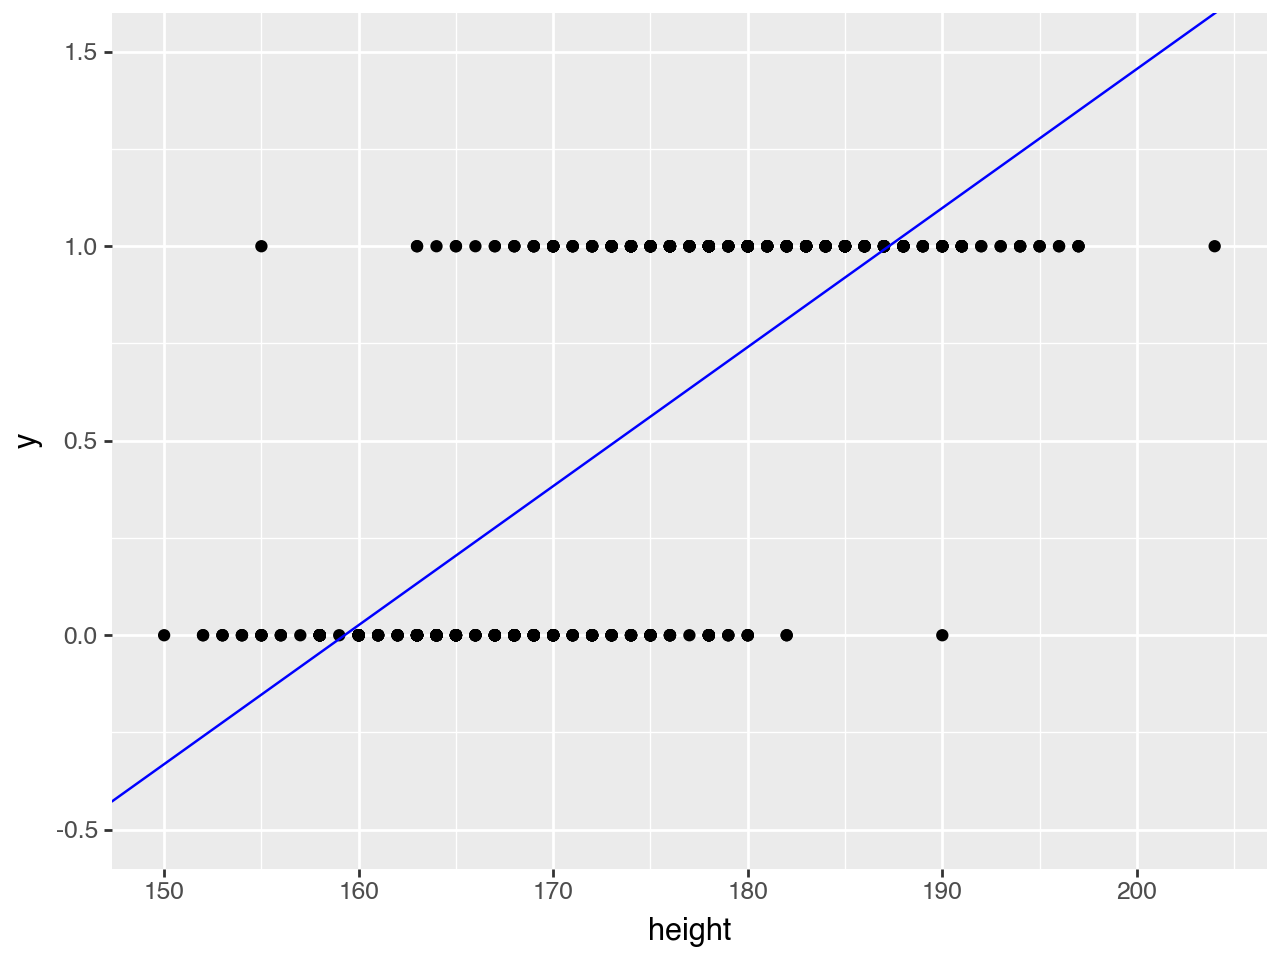

In [3]:
lm_fit0 = smf.ols('y ~ height', heights).fit()

(
    ggplot(heights, aes('height', 'y')) + 
    geom_point() + 
    geom_abline(
        intercept = lm_fit0.params['Intercept'],
        slope = lm_fit0.params['height'],
        color = 'blue'
    ) +
    scale_y_continuous(limits=(-0.5, 1.5))
)

Looking at the figure, we realize that linear regression is not appropriate for this classification task. 

While $y$
 is only defined for the two classes 0 and 1, the regression line does not make that assumption.

We need to step back and consider a different modeling approach for categorical responses. Instead of modeling the response category directly, we could model the proportion of males per height. The following code does exactly this using 2-cm bins to stratify height:

In [4]:
bin_edges = np.arange(heights["height"].min() - 1, heights["height"].max() + 2, 2) # a to b with c long steps 
bin_edges

array([149, 151, 153, 155, 157, 159, 161, 163, 165, 167, 169, 171, 173,
       175, 177, 179, 181, 183, 185, 187, 189, 191, 193, 195, 197, 199,
       201, 203, 205])

In [5]:
heights['height_bins'] = pd.cut(
    heights['height'],
    bins = bin_edges,
    include_lowest= True
)

heights.head()

,height,sex,mother,father,y,height_bins
0,150,F,170.0,177.0,0,"(148.999, 151.0]"
1,152,F,157.0,175.0,0,"(151.0, 153.0]"
2,152,F,155.0,156.0,0,"(151.0, 153.0]"
3,153,F,155.0,175.0,0,"(151.0, 153.0]"
4,153,F,150.0,176.0,0,"(151.0, 153.0]"


In [6]:
heights['mean_height_bins'] = heights.groupby("height_bins")['height'].transform('mean')
heights['prop'] = heights.groupby('height_bins')['y'].transform('mean')

heights.head()

/var/folders/nn/rd9y9hfx7qz4tk9cjwqs2xrh0000gn/T/ipykernel_60806/3297917412.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
/var/folders/nn/rd9y9hfx7qz4tk9cjwqs2xrh0000gn/T/ipykernel_60806/3297917412.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


,height,sex,mother,father,y,height_bins,mean_height_bins,prop
0,150,F,170.0,177.0,0,"(148.999, 151.0]",150.0,0.0
1,152,F,157.0,175.0,0,"(151.0, 153.0]",152.6,0.0
2,152,F,155.0,156.0,0,"(151.0, 153.0]",152.6,0.0
3,153,F,155.0,175.0,0,"(151.0, 153.0]",152.6,0.0
4,153,F,150.0,176.0,0,"(151.0, 153.0]",152.6,0.0


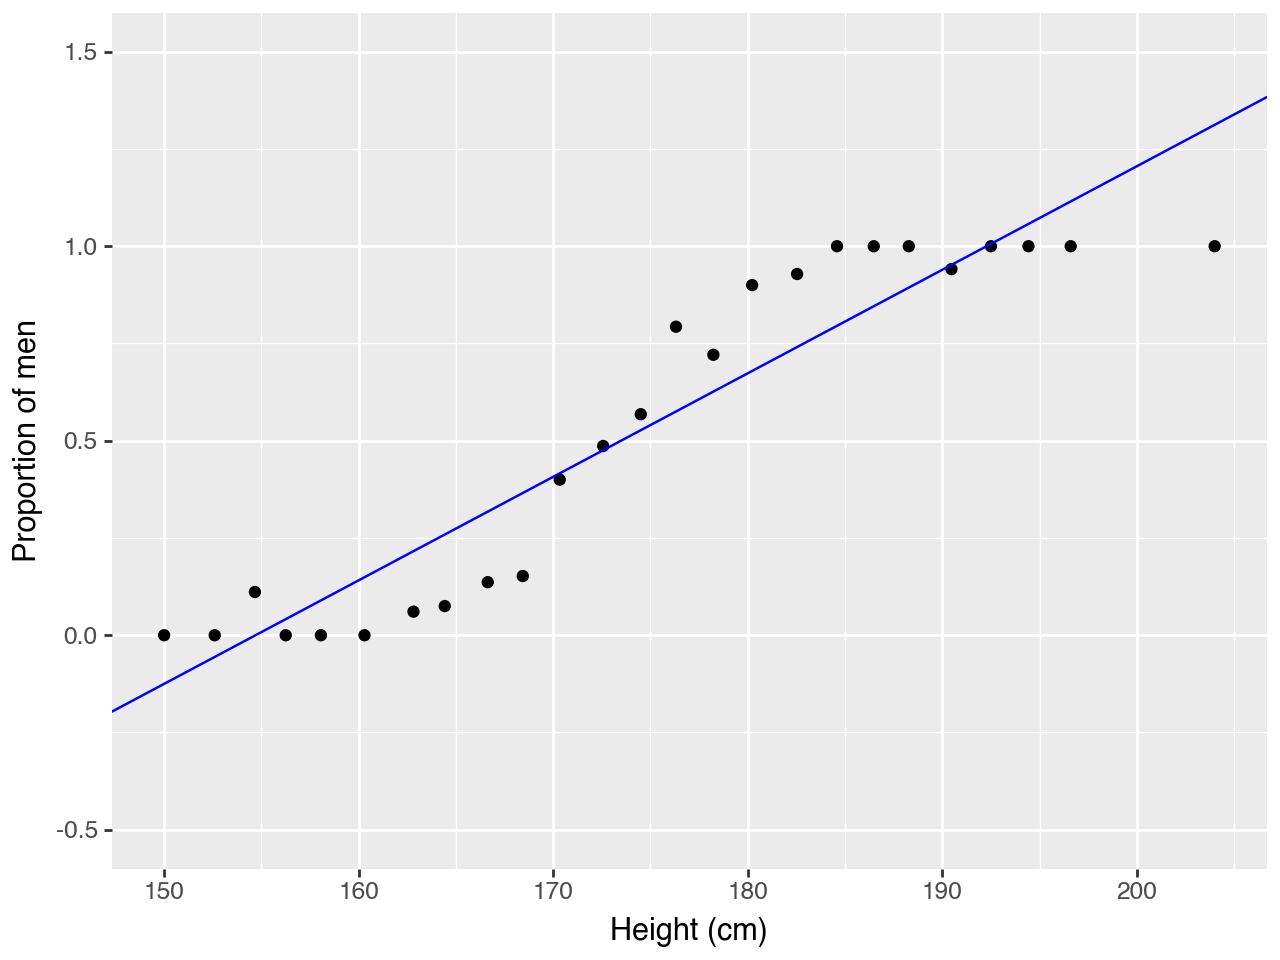

In [7]:
props = (
    heights[["height_bins", "mean_height_bins", "prop"]]
    .drop_duplicates(subset="height_bins")
    .sort_values("mean_height_bins")
)

lm_fit = smf.ols("prop ~ mean_height_bins", data=props).fit()


(
  ggplot(props, aes("mean_height_bins", "prop"))
  + geom_point()
  + xlab("Height (cm)")
  + ylab("Proportion of men")
  + geom_abline(
      intercept=lm_fit.params["Intercept"],
      slope=lm_fit.params["mean_height_bins"],
      color="blue",
    )
  + scale_y_continuous(limits=(-0.5, 1.5))
)


Modeling the proportion of classes rather than the classes themselves already looks a lot better. However, we still have the problem that the predictions can be outside of the [0,1] interval where the proportions are not defined.
Furthermore, the relationship seems to smoothly bend in an S-shape fashion between bins with only females for short heights, and bins with only males for tall heights. This S-shape is not well captured with a linear fit.

Let us now consider another scale for the response, in search for some better linear relationship. Instead of looking at the probabilities of male per stratum, let us consider the odds. The odds for a binary variable $y$ 
 are defined as $\frac{P(y)}{1-P(y)}$. 
 
 We have introduced this concept when defining the Fisher’s test Section 8.3.



We can estimate the overall population odds easily using the table of males and females:

In [8]:
heights["sex"].value_counts()

sex
M     293
F     258
W       2
А       1
M       1
Name: count, dtype: int64

If we estimate $p(\text{male})$ as the proportion of males in the dataset, then the odds of a student being male can be estimated as the ratio of males to females:

$\text{Population odds} \approx \text{male}:\text{female} = \frac{293}{258} = 1.07.$

To investigate how the odds depend on height we can estimate them for each height stratum:

In [9]:
def compute_odds(group: pd.DataFrame) -> float:
  positives = group["y"].sum()
  negatives = (1 - group["y"]).sum()
  if negatives == 0:
    return np.inf
  if positives == 0:
    return 0.0
  return positives / negatives


odds_by_bin = (
  heights.groupby("height_bins")
  .apply(compute_odds)
  .rename("odds")
  .reset_index()
)

props = props.merge(odds_by_bin, on="height_bins", how="left")

props.head()

/var/folders/nn/rd9y9hfx7qz4tk9cjwqs2xrh0000gn/T/ipykernel_60806/3844537755.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
/var/folders/nn/rd9y9hfx7qz4tk9cjwqs2xrh0000gn/T/ipykernel_60806/3844537755.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.


,height_bins,mean_height_bins,prop,odds
0,"(148.999, 151.0]",150.000000,0.000000,0.000
1,"(151.0, 153.0]",152.600000,0.000000,0.000
2,"(153.0, 155.0]",154.666667,0.111111,0.125
3,"(155.0, 157.0]",156.250000,0.000000,0.000
4,"(157.0, 159.0]",158.058824,0.000000,0.000


Plotting the odds in logarithmic scale suggests a linear relationship with height. 

Note that the odds are poorly estimated for high and low values of height, as there are no males in the low strata (division by 0) and no females in the high strata. Hence, we shall ignore the most extreme bins for now.

/opt/anaconda3/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
/opt/anaconda3/lib/python3.13/site-packages/plotnine/layer.py:374: PlotnineWarning: geom_point : Removed 4 rows containing missing values.


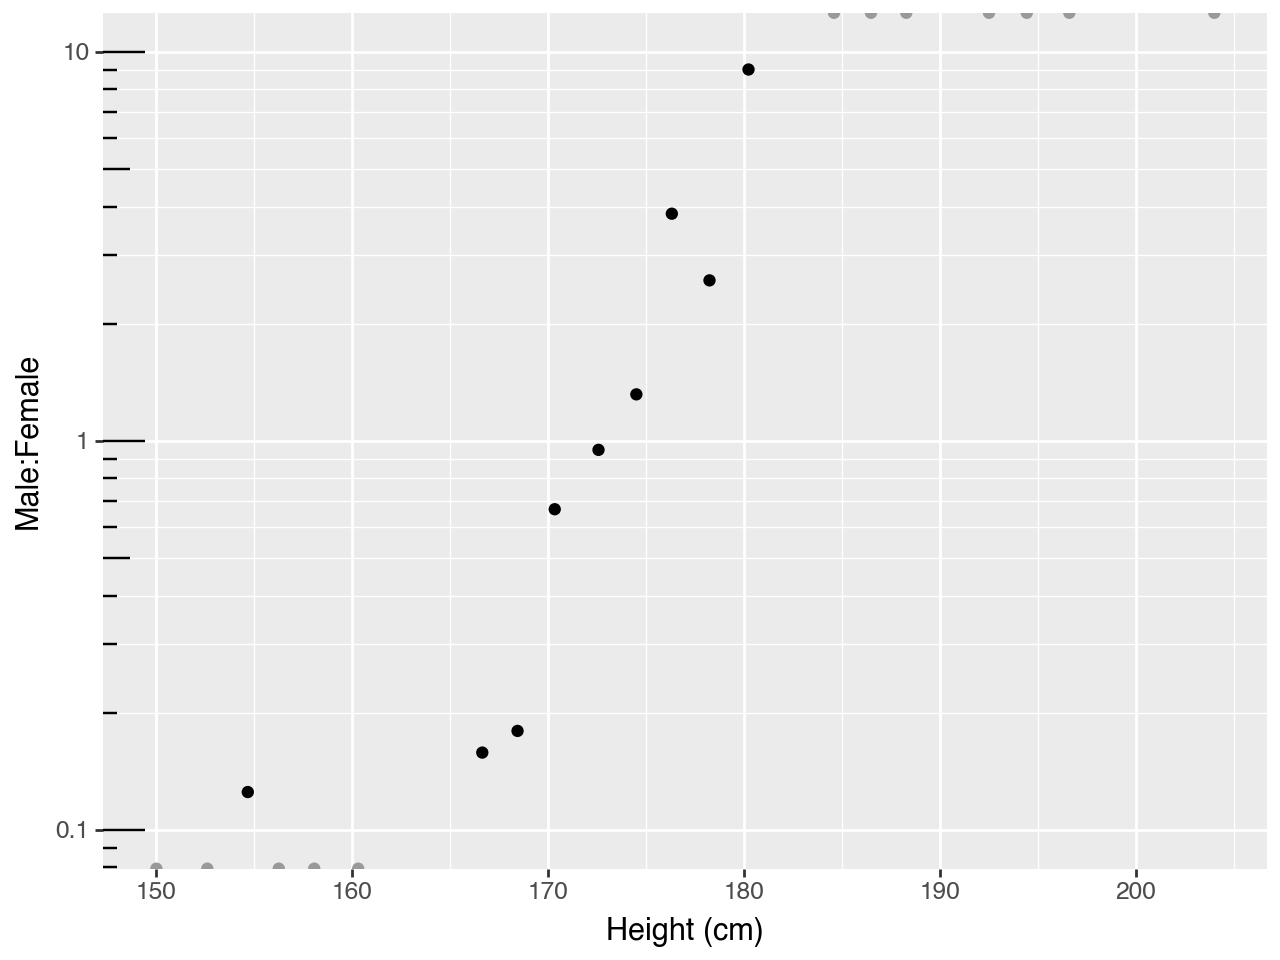

In [10]:
props["valid_odds"] = ~((props["odds"] == 0) |\
  np.isinf(props["odds"]) | props["odds"].isna())

props_valid = props[props["valid_odds"]].copy()

# Major and minor breaks on log10 scale, restricted to the plotted range [0.1, 10]
exponents = np.arange(-1, 2, dtype=float)  # -1, 0, 1 -> 0.1, 1, 10
breaks = 10.0 ** exponents
minor_raw = (
    np.tile(np.arange(1.0, 10.0), len(exponents))
    * np.repeat(10.0 ** exponents, 9)
)
minor_breaks = minor_raw[(minor_raw >= 0.1) & (minor_raw <= 10)]

p_log_odds = (
  ggplot(
      props,
      aes(
          "mean_height_bins",
          "odds",
          color=~(~((props["odds"] == 0) | np.isinf(props["odds"]) | props["odds"].isna())),
      ),
  )
  + geom_point()
  + xlab("Height (cm)")
  + ylab("Male:Female")
  + scale_y_log10(breaks=breaks, minor_breaks=minor_breaks, limits=(0.1, 10))
  + annotation_logticks(sides="l")
    + scale_color_manual(values={False: "#000000", True: "#999999"})
  + theme(legend_position="none")
)

p_log_odds

These observations indicate that, approximately

$$
\log\!\left(\frac{p(\text{male})}{1 - p(\text{male})}\right) \approx \beta_0 + \beta_1\,\text{height}
$$

This makes apparent a useful function for classification tasks, called the logit function, which is defined as :

$$
\operatorname{logit}(z) = \log\!\left(\frac{z}{1 - z}\right), \; z \in (0,1)
$$

Its reverse function, called the logistic function or sigmoid function is equally often used and important. The sigmoid function is denoted $\sigma(z)$
 and it is defined as:

$$
\sigma(z) = \frac{1}{1 + e^{-z}}, \; z \in \mathbb{R}
$$

The sigmoid function is named so due to its S-shaped graph.

It is symmetric and maps real numbers to the $(0,1)$
interval. It is often found in statistics and in physics, as it can describe a variety of naturally occurring phenomena.

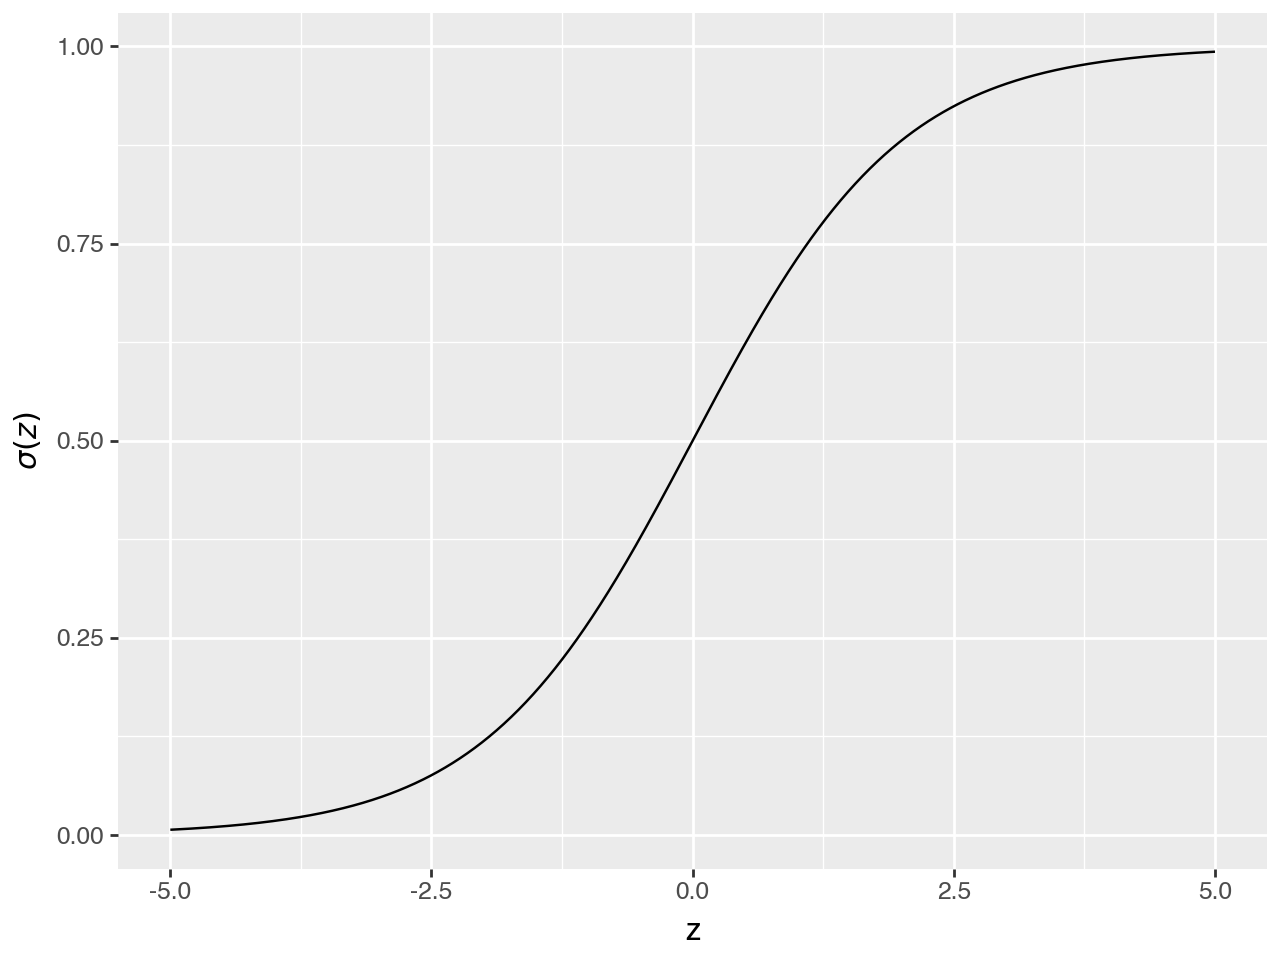

In [11]:
df_sigmoid = pd.DataFrame({"z": np.linspace(-5, 5, 1000)})
df_sigmoid["y"] = 1 / (1 + np.exp(-df_sigmoid["z"]))

(
  ggplot(df_sigmoid, aes("z", "y"))
  + geom_line()
  + xlab("z")
  + ylab(r"$\sigma(z)$")
)

Hence, we found a linear relationship!

We could in principle make predictions given height of log-odds and, passing them through the sigmoid, of probabilities of being a male.

However, the approach we laid down is not satisfactory. It requires some arbitrary binning. 

We are not able to make use of the data in the most extreme bins which have either no male or no female. Also the log-odds of some bins are better estimated than others. Estimating odds of say 0.5 by observing 1 males and 2 females is not as precise as if we observe 100 males and 200 females.

 This uncertainty is not factored in with our approach. We need to step back to theory.

-------

## From Linear Regression to Logistic Regression

Remember that in Section Section 10.2.2, we mentioned that linear regression can be derived equivalently with the least squares criterion or with the maximum likelihood criterion.

 It turns out that it is the maximum likelihood criterion that will allow us to derive a principled way to model the classification problem. 

To see this, we start from the likelihood of the linear regression model and will adapt it to our new problem. This was (Section Section 10.2.2):

$$
\begin{aligned}
p(\mathbf{y} \mid \mathbf{X})
&= \prod_i p(y_i \mid x_i)
&& \text{(conditional independence)} \\[0.8em]
p(y_i \mid x_i)
&= \mathcal{N}(y_i \mid \mu_i, \sigma^2) \\[0.8em]
\mu_i
&= \beta_0 + \sum_{j=1}^{p} \beta_j x_{ij}
\end{aligned}
$$

Hence, linear regression models $\mu_i$ := $E[y| x_{i1},..., x_{ip}]$

the expectation of the outcome conditioned on the features. In particular, this conditional expectation is modeled as a linear combination of the features.

Rather than predicting an unbounded continuous outcome given some features, the classification problem can be approached by predicting the probability of a class given some features (ex. predicting the probability of the student being male given that the height is 160 cm). Modeling a probability with a linear function is not ideal because we can make predictions <0 or >1. Logistic regression addresses this problem by using the logistic function discussed above, which maps linear combinations of features to the (0,1) interval.

A logistic regression models the data:

$$
\begin{aligned}
p(\mathbf{y} \mid \mathbf{X})
&= \prod_i p(y_i \mid x_i)
&& \text{(conditional independence)} \\[0.8em]
p(y_i \mid x_i)
&= \tilde{B}(y_i \mid 1, \mu_i) \\[0.8em]
\mu_i
:= \mathbb{E}[y_i \mid x_i]
&= \sigma\!\left(\beta_0 + \sum_{j=1}^{p} \beta_j x_{ij}\right)
\end{aligned}
$$

where $B(y_i | 1, \mu_i)$
 stands for the binomial distribution for 1 trial and probability $\mu_i$
, which in this particular case, where the number of trials is one, is also called a Bernoulli distribution. The Bernoulli distribution is a discrete distribution where there are two possible outcomes: failure ($y = 0$
) or success ($y = 1$
) (ex. 1 trial of tossing a coin: heads or tails). The success occurs with probability $\mu$
 and failure occurs with probability $1-\mu$
.

In the case of logistic regression, the probability $\mu$
 is the expectation of the success class (y=1) conditioned on the features, $E[y_i = 1 | x_{i1}, ... , x_{ip}] = \mu_i$
.



We can alternatively write an equivalent expression to the latter by using the inverse function of the sigmoid, the logit function:

$$
\eta_i := \operatorname{logit}(\mu_i) = \beta_0 + \sum_{j=1}^{p} \beta_j x_{ij}
$$

-------

## Maximum likelihood estimates and the cross-entropy criterion

As for linear regression, we estimate the parameters of the model using the maximum likelihood criterion. Plugging the binomial probability and taking the logarithm, we obtain:

$$

\begin{aligned}
\arg\max_{\boldsymbol{\beta}}
\prod_i p(y_i \mid x_i, \boldsymbol{\beta})
&= \arg\max_{\boldsymbol{\beta}}
\sum_i \log\!\bigl(B(y_i \mid 1, \mu_i(x_i,\boldsymbol{\beta}))\bigr) \\[0.8em]
&= \arg\min_{\boldsymbol{\beta}}
\left[
- \sum_i
\Bigl(
y_i \log \mu_i(x_i,\boldsymbol{\beta})
+ (1 - y_i)\log\!\bigl(1 - \mu_i(x_i,\boldsymbol{\beta})\bigr)
\Bigr)
\right].
\end{aligned}
$$

The term:

$$
- \sum_i
\Bigl(
y_i \log \mu_i(x_i,\boldsymbol{\beta})
+ (1 - y_i)\log\!\bigl(1 - \mu_i(x_i,\boldsymbol{\beta})\bigr)
\Bigr)
$$

is called the `cross-entropy` between the model predictions (the predicted probabilities $\mu_i$
) and the observations $y_i$.

Hence, maximum likelihood leads to a different minimization objective for classification than for linear regression. For classification, we are not minimizing the squared errors but the cross-entropy.

These minimization objectives are employed by a wide variety of models.

Modern neural networks, which model complex non-linear relationships between input and output, also typically use cross-entropy to optimize their parameters for classification tasks and typically use the least squares criterion when it comes to quantitative predictions.

It turns out that there is no analytical solution to the maximum likelihood estimates of a logistic regression. Instead, algorithms are employed that numerically minimize cross-entropy until reaching parameter values that cannot be optimized further. For logistic regression, such algorithms are pretty fast and robust due to good mathematical properties of the problem which apply in typical real-life datasets.



-------

## Logistic regression as a generalized linear model

Generalized linear models (GLM) generalize linear regression by allowing the linear model to be related to the response variable via a link function and by allowing the magnitude of the variance of each measurement to be a function of its predicted value.

As we have seen in the special case of the logistic regression, which is an instance of a GLM, we changed the linear regression by applying a transformation to the linear combination of the features in order to use it for another type of predictions.

* Logistic regression is one instance of generalized linear models, which all exploit the same idea:

    * A probability distribution from the exponential family
        * Logistic regression: Bernoulli

    * A linear predictor $\eta = X \beta$
        * Logistic regression: $\eta_i := \operatorname{logit}(\mu_i) = \beta_0 + \sum_{j=1}^{p} \beta_j x_{ij}$

    * A link function $g$ such that $E[y] = \mu = g^{-1}(\eta)$
        * Logistic regression: $g = \text{logit}$ and $g^{-1} = \text{sigmoid}$

The inverse of the link function is called the activation function, which in logistic regression is the logistic function.

Other popular examples of GLMs include Poisson regression  and Gamma regression.

------

## Logistic regression with Python

To fit a logistic regression to our data we can use the function `glm` from `statsmodels`, which stands for generalized linear model, with a binomial family. The fitted model can be applied to data (seen or unseen) using `predict`. 

By default it returns the predicted probabilities on the natural scale.

In [12]:
logistic_fit = smf.glm("y ~ height", data=heights, family=sm.families.Binomial()).fit()

heights["mu_hat"] = logistic_fit.predict(heights)
heights.head()

,height,sex,mother,father,y,height_bins,mean_height_bins,prop,mu_hat
0,150,F,170.0,177.0,0,"(148.999, 151.0]",150.0,0.0,0.001445
1,152,F,157.0,175.0,0,"(151.0, 153.0]",152.6,0.0,0.002541
2,152,F,155.0,156.0,0,"(151.0, 153.0]",152.6,0.0,0.002541
3,153,F,155.0,175.0,0,"(151.0, 153.0]",152.6,0.0,0.003370
4,153,F,150.0,176.0,0,"(151.0, 153.0]",152.6,0.0,0.003370


Here are the predicted values using logistic regression (red) compared to a linear regression of the proportions (black). Overall, logistic regression fits better to our data and fixes the issue of having predictions outside the [0,1] interval.



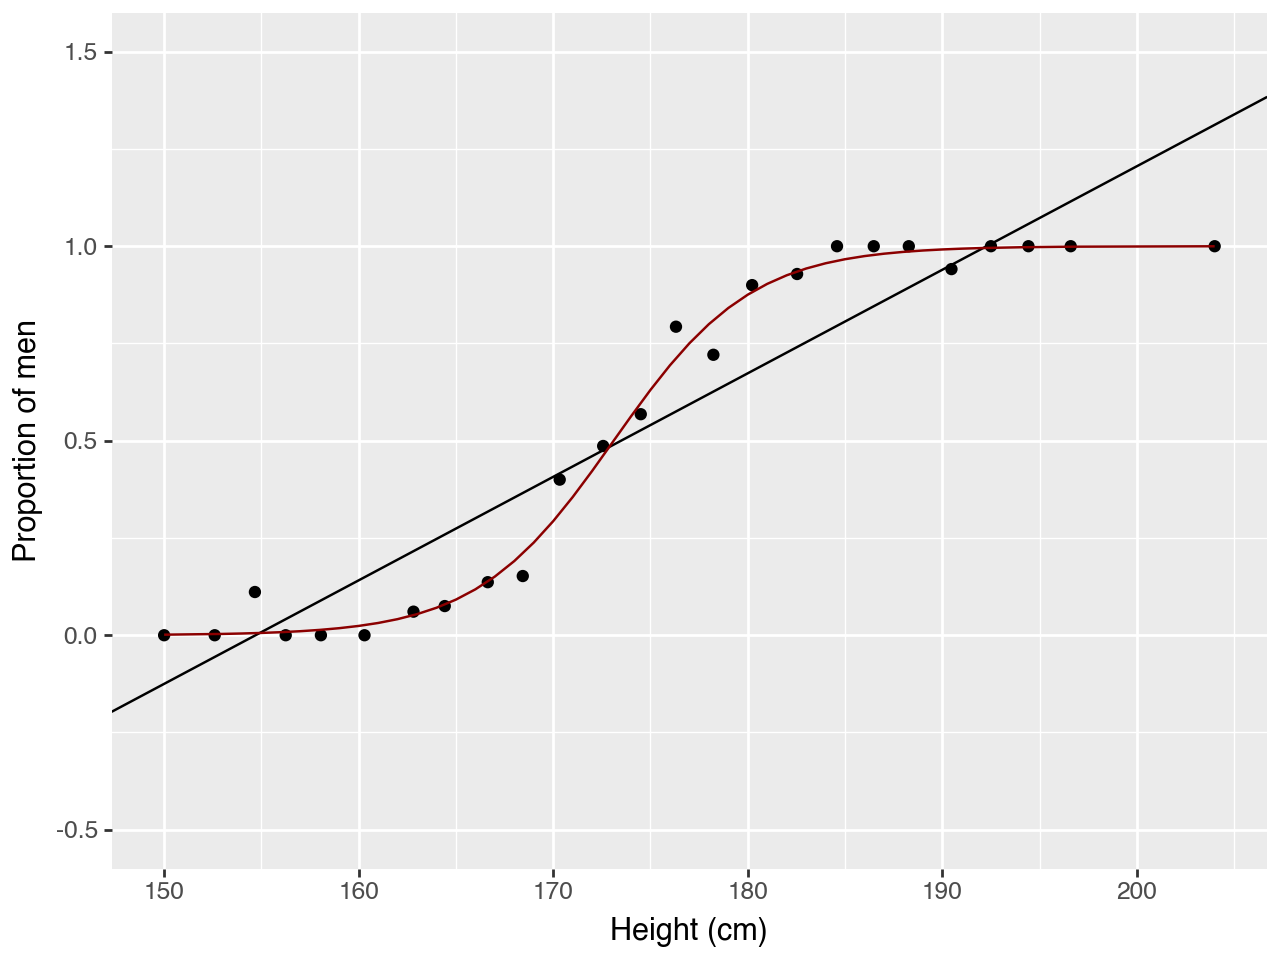

In [13]:
(
  ggplot(props, aes("mean_height_bins", "prop"))
  + geom_point()
  + xlab("Height (cm)")
  + ylab("Proportion of men")
  + geom_abline(
      intercept=lm_fit.params["Intercept"],
      slope=lm_fit.params["mean_height_bins"],
  )
  + geom_line(
      data=heights.sort_values("height"),
      mapping=aes("height", "mu_hat"),
      color="darkred",
  )
  + scale_y_continuous(limits=(-0.5, 1.5))
)

----

## Overview plot of the univariate example

We finish this section, for didactic purposes, with an overview plot (Figure below) from the raw data down to the logistic fit.

In [14]:
p_hist_male = (
  ggplot(heights[heights["sex"] == "M"], aes("height"))
  + geom_histogram(bins=30)
  + scale_x_continuous(limits=(150, 200))
  + labs(x="Height (cm)", y="Number of Males")
)

p_hist_female = (
  ggplot(heights[heights["sex"] == "F"], aes("height"))
  + geom_histogram(bins=30)
  + scale_x_continuous(limits=(150, 200))
  + labs(x="Height (cm)", y="Number of Females")
)

p_fit_male = (
  ggplot(props, aes("mean_height_bins", "prop"))
  + geom_point()
  + labs(x="Height (cm)", y="Estimated P(Male)")
  + geom_line(
      data=heights.sort_values("height"),
      mapping=aes("height", "mu_hat"),
      color="darkred",
  )
  + scale_x_continuous(limits=(150, 200))
)

p_log_odds_plot = p_log_odds + scale_x_continuous(limits=(150, 200))

/opt/anaconda3/lib/python3.13/site-packages/plotnine/layer.py:293: PlotnineWarning: stat_bin : Removed 1 rows containing non-finite values.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/layer.py:374: PlotnineWarning: geom_histogram : Removed 2 rows containing missing values.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/layer.py:374: PlotnineWarning: geom_histogram : Removed 2 rows containing missing values.
/opt/anaconda3/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
/opt/anaconda3/lib/python3.13/site-packages/plotnine/layer.py:374: PlotnineWarning: geom_point : Removed 5 rows containing missing values.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/layer.py:374: PlotnineWarning: geom_point : Removed 1 rows containing missing values.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/geoms/geom_path.py:100: PlotnineWarning: geom_path: Removed 1 rows containing missing values.


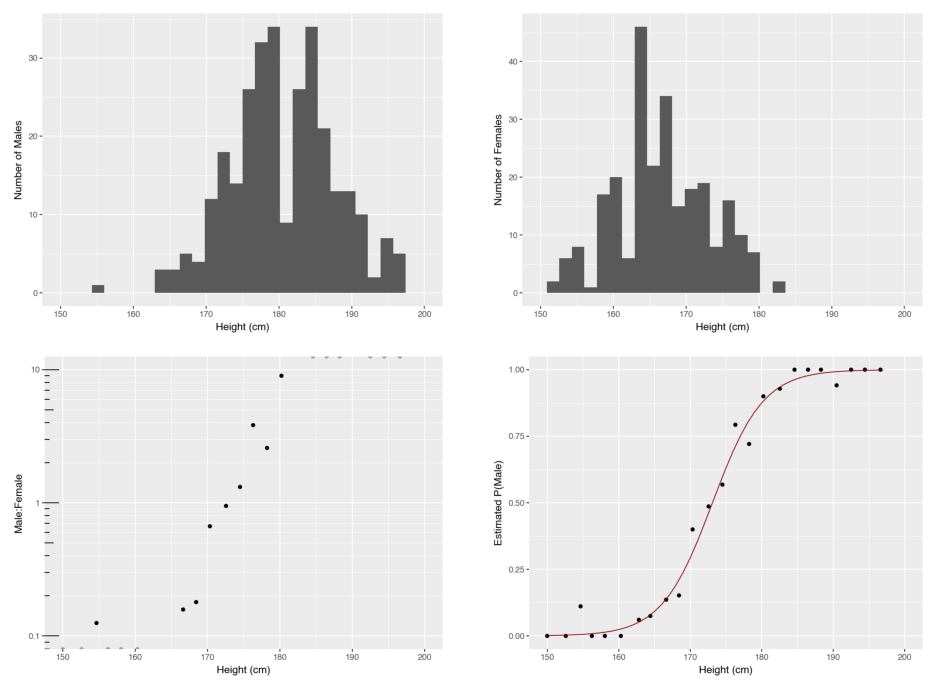

In [21]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import tempfile, os

def gg_to_img(p, dpi=150):
    # geçici dosyaya kaydet
    fd, path = tempfile.mkstemp(suffix=".png")
    os.close(fd)
    p.save(path, dpi=dpi, verbose=False)   # plotnine save
    img = mpimg.imread(path)
    os.remove(path)
    return img

imgs = [
    gg_to_img(p_hist_male),
    gg_to_img(p_hist_female),
    gg_to_img(p_log_odds_plot),
    gg_to_img(p_fit_male),
]

fig, axes = plt.subplots(2, 2, figsize=(10, 7))
axes = axes.ravel()
for ax, img in zip(axes, imgs):
    ax.imshow(img)
    ax.axis("off")
plt.tight_layout()
plt.show()

-----

##  Interpreting a logistic regression fit

### Predicted odds

In logistic regression, the logit of the predicted response/probability for a certain input is the predicted log odds for the positive class (y=1) on that input. For example, for a height of 178 cm the log odds is:

In [23]:
log_odds_178 = (
  logistic_fit.params["Intercept"]
  + logistic_fit.params["height"] * 178
)
log_odds_178


np.float64(1.3840630453878475)

To get the odds we can exponentiate this number. The obtained result means that the odds for someone to be a male (positive class) at height 178 cm is:

In [26]:
np.exp(log_odds_178)

np.float64(3.991084687209611)

### Coefficients Of The Logistic Regression

The $\beta$ values from logistic regression are log odds ratios associated with an increase by one unit of the corresponding explanatory variable. 

Odds ratios can thus be obtained by applying `np.exp`.



In [27]:
logistic_fit.params


Intercept   -48.980144
height        0.282945
dtype: float64

In [28]:
OR_height = np.exp(logistic_fit.params["height"])
OR_height

np.float64(1.3270321523279396)

As we have seen, in logistic regression the log odds is predicted as a linear combination of the features, where the coefficients are log odds ratios. 

Therefore, in our example of predicting sex from height, increasing the height by $h$
 centimeters changes the log odds by approximately $h \times 0.292$
, or equivalently, it multiplies the odds by approximately $e^{h \times 0.292} = 1.339^h$
.

--------

## Effects on Probabilities

One important difference between linear regression and logistic regression is that for the latter, the relationship between input and predicted value is not linear.

A drastic example is shown in below image, where increases of 5 cm produce different increases in the probability for male depending on the starting point.

If we start at odds 1:1, the probability is 0.5, and our corresponding height can be obtained by solving the equation for height on:

$$
\log(\text{odds}) = \beta_0 + \beta_1 \times \text{height}
$$

where $\beta_0$
 and $\beta_1$
 are the coefficients of the logistic regression. 

This gives us a height value of 173.1. Note that the point of steepest increase in the logistic curve corresponds to the predicted probability of 0.5

In [35]:
height_p05 = - logistic_fit.params['Intercept'] / logistic_fit.params['height']
height_p05

np.float64(173.10836692029466)


An increase in 5 cm leads us to a probability of:

In [38]:
prob_5 = logistic_fit.predict(pd.DataFrame({'height': [height_p05 + 5]}))[0]
prob_5

np.float64(0.8045101183869746)

If we increase 5 cm again, then we will have a predicted probability for male of:

In [44]:
prob_10 = logistic_fit.predict(pd.DataFrame({'height': [height_p05 + 10]}))[0]
prob_10

np.float64(0.9442466462275924)


An increase in height from 173.1 cm to 178.1 cm increases the estimated probability by 0.31, 

while an increase in height from 178.1 cm to 183.1 cm increases the estimated probability by 0.14.

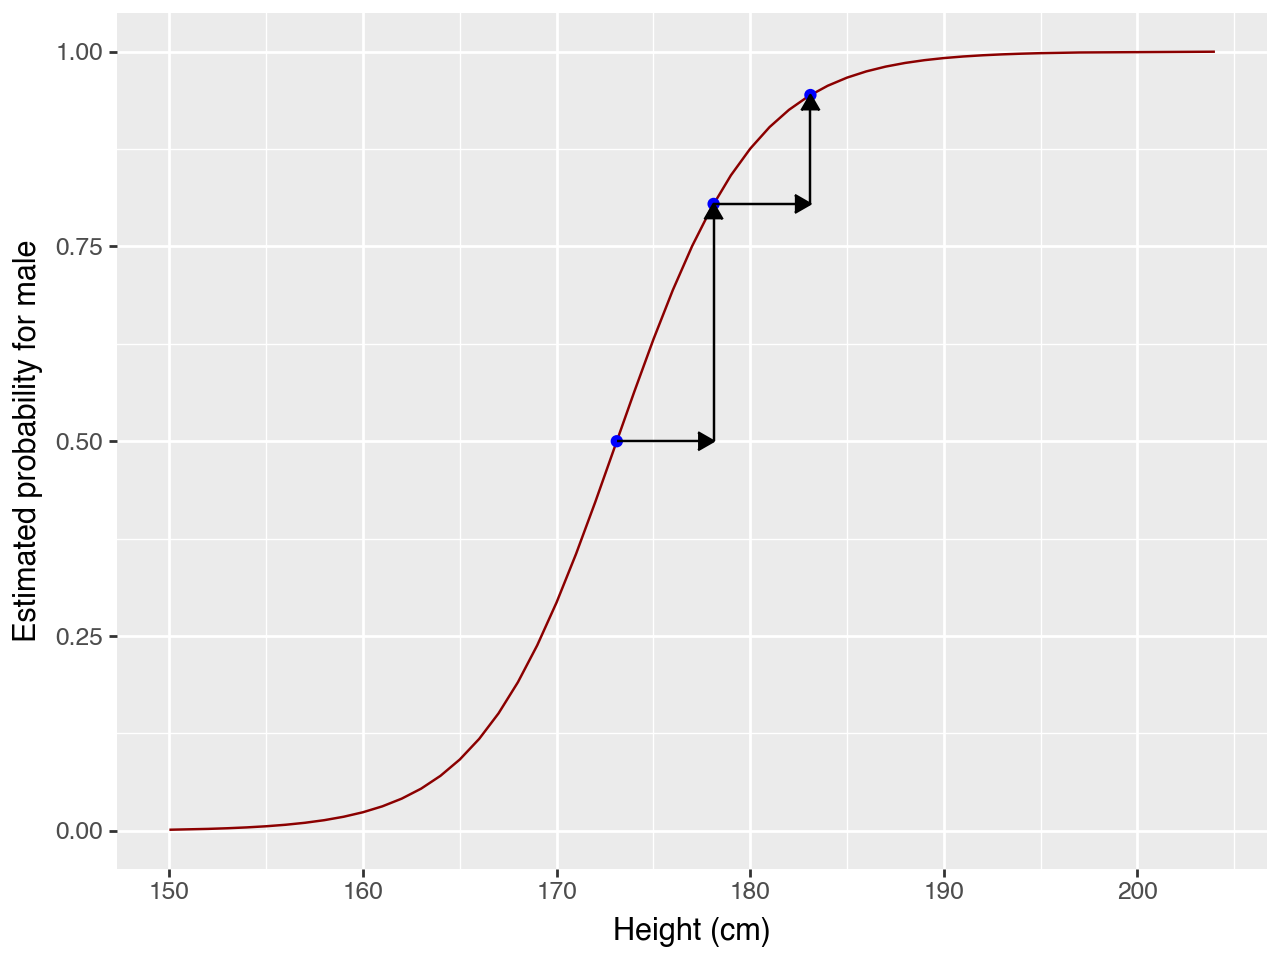

In [45]:
transitions_df = pd.DataFrame(
    {
    "height": [height_p05, height_p05 + 5, height_p05 + 10],
        "prob": [0.5, prob_5, prob_10],
    }
)

segments_df = pd.DataFrame(
    {
    "x": [height_p05, height_p05 + 5, height_p05 + 5, height_p05 + 10],
    "y": [0.5, 0.5, prob_5, prob_5],
    "xend": [height_p05 + 5, height_p05 + 5, height_p05 + 10, height_p05 + 10],
        "yend": [0.5, prob_5, prob_5, prob_10],
    }
)

(
  ggplot(heights, aes("height", "mu_hat"))
  + geom_line(color="darkred")
  + geom_point(data=transitions_df, mapping=aes("height", "prob"), color="blue")
  + geom_segment(
      data=segments_df,
      mapping=aes(x="x", y="y", xend="xend", yend="yend"),
      arrow=arrow(length=0.1, ends="last", type="closed"),
      color="black",
  )
  + xlab("Height (cm)")
  + ylab("Estimated probability for male")
)

-------

##  Class imbalance

Now we turn to a situation of class imbalance, which refers to having one class with substantially more instances than the other. 

Let’s create a class imbalanced heights dataset with ~20% males and ~80% females.

In [50]:
np.random.seed(123)

male_df = heights[heights['sex'] == 'M']
female_df = heights[heights['sex'] == 'F']


target_males = max(1, int(0.25 * len(female_df)))
male_sample = male_df.sample(n = target_males, random_state=123)

imbalanced_heights = pd.concat([female_df, male_sample], ignore_index= True)
imbalanced_heights['sex'].value_counts()

sex
F    258
M     64
Name: count, dtype: int64

Now let’s fit a logistic regression as done previously:

In [51]:
logistic_fit_imbalanced = smf.glm('y ~ height',data= imbalanced_heights, family = sm.families.Binomial() ).fit()

In [53]:
print('\n Coefficients:\n', logistic_fit_imbalanced.params.round(4).to_string())


 Coefficients:
 Intercept   -56.6903
height        0.3187


Now we can plot our logistic fit to the imbalanced dataset and compare it to our previous logistic fit obtained in the balanced dataset.

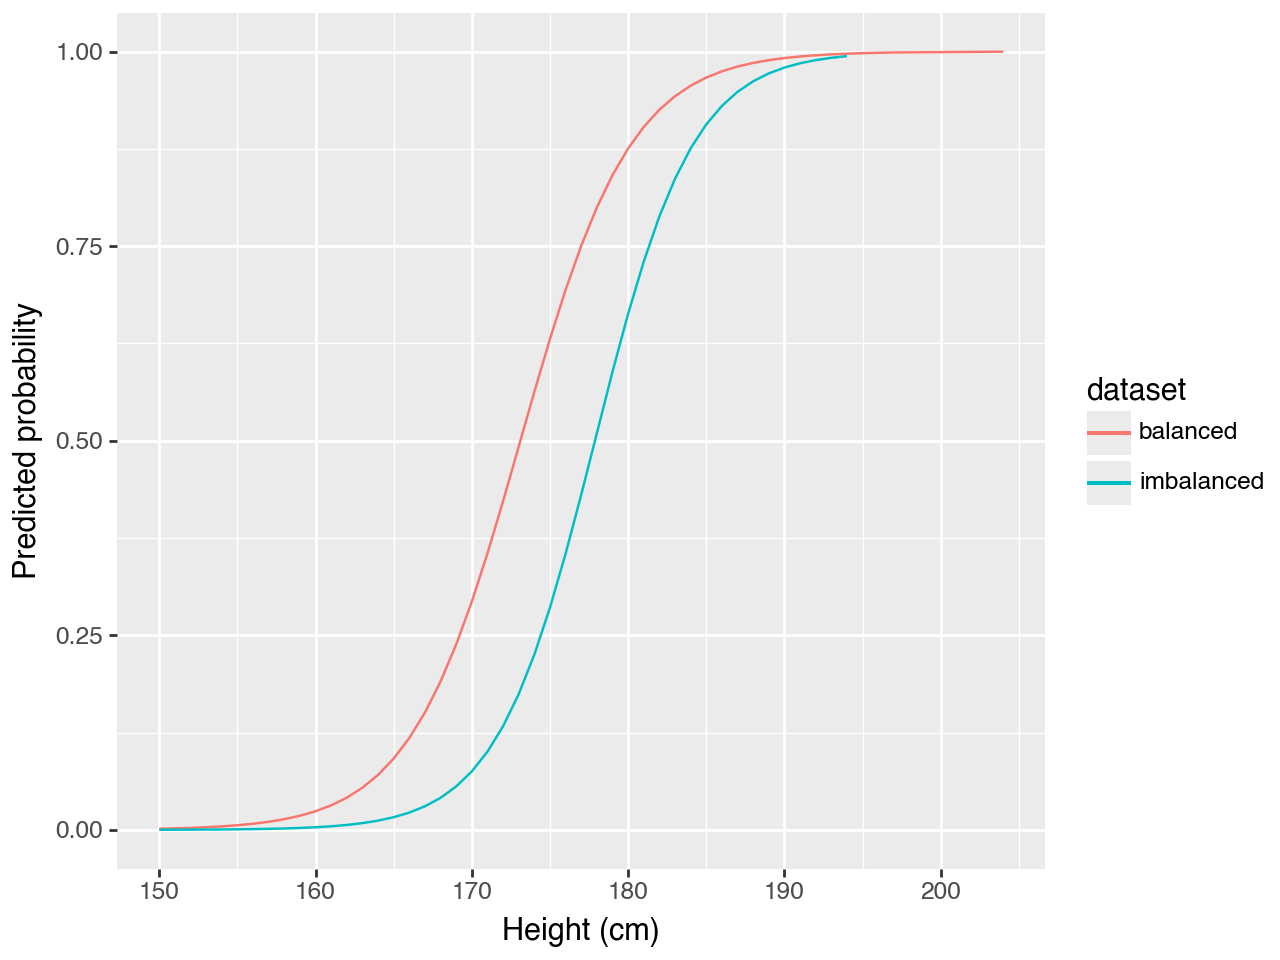

In [54]:
imbalanced_heights["mu_hat"] = logistic_fit_imbalanced.predict(imbalanced_heights)
imbalanced_heights["dataset"] = "imbalanced"

heights_balanced = heights.copy()
heights_balanced["dataset"] = "balanced"

curve_df = pd.concat(
    [
        heights_balanced[["height", "mu_hat", "dataset"]],
        imbalanced_heights[["height", "mu_hat", "dataset"]],
    ],
    ignore_index=True,
).sort_values(["dataset", "height"])

(
  ggplot(curve_df, aes("height", "mu_hat", color="dataset"))
  + geom_line()
  + xlab("Height (cm)")
  + ylab("Predicted probability")
)

The logistic fit on the imbalanced dataset looks different. 

In particular, the curve has been shifted to the right. 

The predicted probability of being male for a given height is lower compared to the balanced logistic fit. Let’s look at the logit of the predicted response and compare it to the previous balanced dataset.

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/genmod/generalized_linear_model.py:985: FutureWarning: linear keyword is deprecated, use which="linear"
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/genmod/generalized_linear_model.py:985: FutureWarning: linear keyword is deprecated, use which="linear"


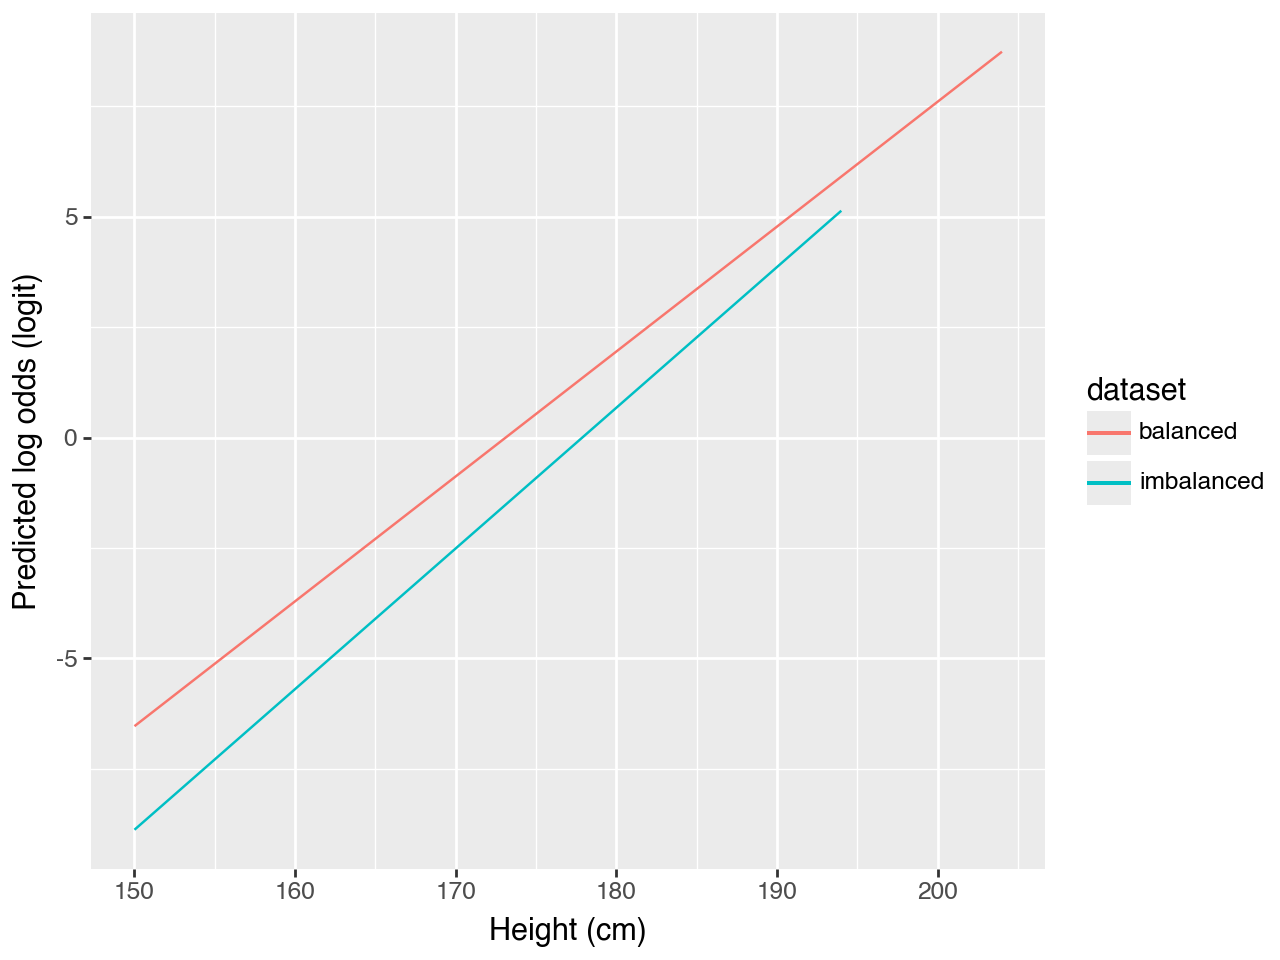

In [55]:
heights_balanced["logistic_logit"] = logistic_fit.predict(
  heights_balanced, linear=True
)

imbalanced_heights["logistic_logit"] = logistic_fit_imbalanced.predict(
  imbalanced_heights, linear=True
)

logit_df = pd.concat(
    [
        heights_balanced[["height", "logistic_logit", "dataset"]],
        imbalanced_heights[["height", "logistic_logit", "dataset"]],
    ],
    ignore_index=True,
).sort_values(["dataset", "height"])

(
  ggplot(logit_df, aes("height", "logistic_logit", color="dataset"))
  + geom_line()
  + xlab("Height (cm)")
  + ylab("Predicted log odds (logit)")
)


As seen from this figure, the intercept of the logistic regression is now lower and the lines are nearly parallel. 

This means that the estimated log odds for male in the imbalanced logistic fit are generally lower. Indeed, if we have lower quantities of males for each value of height in general, then the odds for male will be overall lower for all heights.

Why can the effect of class imbalance be seen on the intercept? 

While the proportion among males in each stratum are independent of the number of males, the ratios of males over females scales with the overall number of males. 

Hence, The odds male:female per stratum proportionally change when the overall population odds change. In a log scale this translates into an added constant and thus a vertical shift. In other words, changes in class imbalance affects the intercept $\beta_0$
 of a logistic regression by adding a constant

---

# Multiple Logistic regression

Until now, we have performed logistic regression with one variable only as input. 

However, in our formulation of logistic regression we allowed a set of features to predict the probability of the class. 

In multiple logistic regression there can be several input variables. 

We can use multiple logistic regression to predict the student’s sex given the heights of the student and of the student’s parents.

In [56]:
multi_logistic_fit = smf.glm(
  "y ~ height + mother + father", data=heights, family=sm.families.Binomial()
).fit()

print("\nCoefficients:\n", multi_logistic_fit.params.round(4).to_string())


Coefficients:
 Intercept   -24.3625
height        0.4809
mother       -0.1725
father       -0.1719


Similarly to the previous univariate logistic fit, an increase in the student’s height increases the odds for male. 

Furthermore, this model gives negative coefficients to the height of the mother and of the father.

This makes sense: the taller either parent, the taller the children. It is therefore more likely that a tall person is a female, if the parents are tall.

Is this model, which integrates the heights of the parent, doing a better job at predicting sex than the simpler model we first developed? And if so by how much? We will see now ways to answer these questions.

------

# Assessing the Performance of a Classifier

## Classification with logistic Regression

Logistic regression predicts a probability, therefore it conveys some uncertainty in the prediction.

Classification implies that we attribute one class per instance, and not a probability.

Hard classification is usually performed by the following simple rule: If $\mu > 0.5$ 
 (or equivalently $\eta > 0$
), predict class $1$, else predict class $0$.

Let’s follow this rule for the previous multiple logistic regression and inspect the predictions of the classes male (0) and female (1) by computing a contingency table between the predicted and true classes:

In [57]:
heights["y_multi_pred"] = (multi_logistic_fit.predict(heights) >= 0.5).astype(int)
pd.crosstab(heights["y"], heights["y_multi_pred"])

y_multi_pred,0,1
y,,
0,237,25
1,34,259


34 males were predicted as female (false negatives) and 25 females were predicted as male (false positives).

## Confusion Matrix

The previous table is also termed confusion matrix. The following figure depicts the structure of a confusion matrix:

<img src = 'images/Logistic Regression Data Analysis.png' width = 900>

Such matrix allows us to assess the quality of the classifications. A classifier should maximize true positives (TP) and true negatives (TN), and minimize false negatives (FN) and false positives (FP).

-----

## Classification Performance Metrics

From the confusion matrix, various quality metrics have been defined. Moreover, depending on the application domain, the same quantities are referred to with different names. 

We focus here on a few key metrics:

* The `sensitivity` refers to the fraction of actual positives that is predicted to be positive:
    * $\text{Sensitivity} = \frac{TP}{P} = \frac{TP}{TP + FN}$


* The `specificity` refers to the fraction of actual negatives that is predicted to be negative:
    * $\text{Specificity} = \frac{TN}{N} = \frac{TN}{TN + FP}$

The specificity is also known as “true negative rate” or “sensitivity of the negative class”

* The `precision` refers to the fraction of predicted positives that are indeed positives
    * $\text{Precision} = \frac{TP}{TP + FP}$

The precision is also called the positive predictive value. 

Note that, in the hypothesis testing context, we discussed a related concept, the false discovery rate (FDR). The FDR relates to the precision as follows:

$FDR = E[\frac{FP}{TP + FP}] = E[1-\frac{TP}{TP + FP}] = 1 - E[\text{Precision}]$ 

* The `accuracy` refers to the fraction of all instances that are correctly classified:
    * $\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}$

--------

## Choosing a Classification Cutoff

Many classification methods do not directly assign a class, but rather output a quantitative score. 

For instance, the logistic regression predicts a probability. Other methods may output a real number that is not aimed to represent a probability yet for which the larger, the more likely the class is positive.

This would be the case if we had insisted in using linear regression as we first attempted at the start of this Chapter, but it is also the case if we use the logit instead of the predicted probability in logistic regression or for classifiers reporting a score on an arbitrary scale like support vector machines.

Hence, we typically need to set a cutoff above which we classify as “positive”. Previously we defined our cutoff at $\mu = 0.5$
 or $\text{logit}(\mu) = 0$
, but it was an arbitrary decision, we could have chosen a different one. 

The choice of the cutoff influences the performance metrics.

Let’s go back to the example of predicting the sex of the student given its height and consider the logits of the logistic regression as scores. 

If the logistic regression predictions are somewhat informative, we expect the distribution of the scores for the negative and positive classes to be to some extent separated. 

Indeed, as depicted in Figure below, most students can be correctly separated in male or female given its score. However, a certain amount of students from different sexes have overlapping scores.

<img src = 'images/Logistic Regression Visualization.png' width = 600>

As seen from the previous figure, picking a cutoff at a certain value like the one in the dashed line, will produce classifications which are false positives or false negatives.

<img src = 'images/Logistic Regression Visualization (1).png' width = 600>

Now, every female student is classified as such (True negative (TN)), however some male students are classified as female (False negative (FN)). 

Choosing the cutoff is a trade-off between sensitivity and specificity. 

<u>How the trade-off is made is problem-dependent.</u>

-------

# ROC Curve 

The receiver operating characteristic curve or ROC curve is a way of evaluating the quality of a binary classifier at different cutoffs.

It describes on the x axis the false positive rate (1-specificity), $FPR = \frac{FP}{N} = \frac{FP}{FP+TN}$  

, and on the y axis the true positive rate (sensitivity), $TPR = \frac{TP}{P} = \frac{TP}{TP + FN}$

Let’s plot the ROC curve for the univariate logistic regression model we fitted on heights and the ROC curve. As comparisons we look also at a random classifier (i.e. a model that outputs random values for probabilities of positive class). 

To do this we use functions from `sklearn.metrics` to compute ROC curves and plot them with `plotnine`.

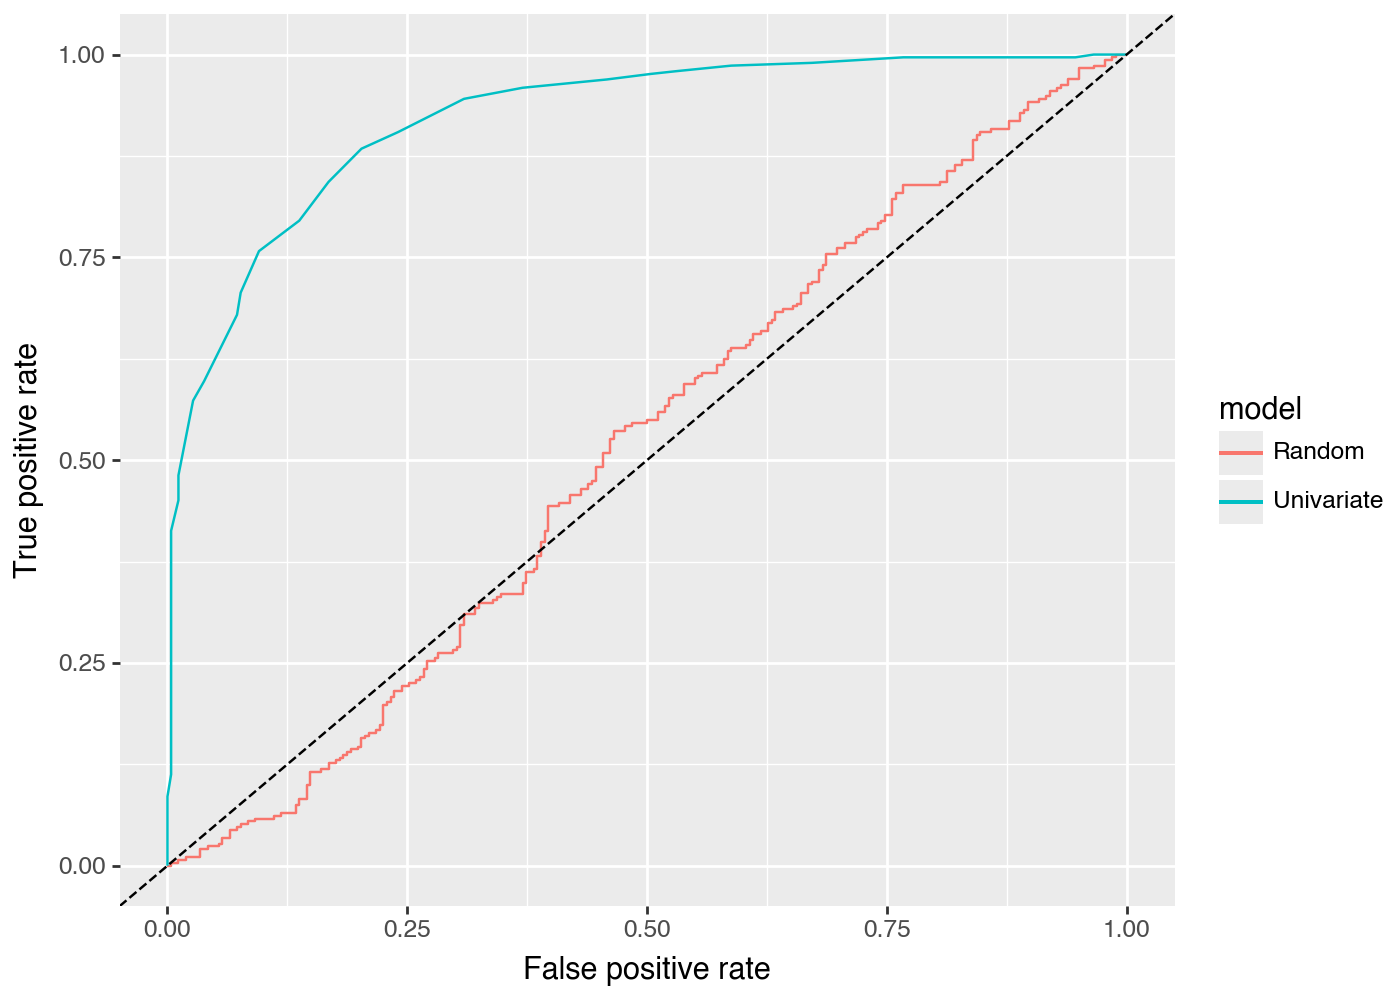

In [ ]:
heights["random_scores"] = np.random.rand(len(heights))

roc_rows = []
for label, scores in [
  ("Univariate", heights["mu_hat"]),
  ("Random", heights["random_scores"])]:
  
    fpr, tpr, _ = roc_curve(heights["y"], scores) # fpr -> false postivite rate // tpr -> true positive rate
    
    roc_rows.append(
        pd.DataFrame({"fpr": fpr, "tpr": tpr, "model": label})
    )

roc_df = pd.concat(roc_rows, ignore_index=True)

ggroc = (
  ggplot(roc_df, aes("fpr", "tpr", color="model"))
  + geom_line()
  + geom_abline(intercept=0, slope=1, linetype="dashed")
  + labs(x="False positive rate", y="True positive rate")
  + theme(figure_size=(7, 5))
)
ggroc

The points along the lines represent the cutoff value. 

If all instances are classified as positive (cutoff=0) then the false positive rate is 1 and so is the true positive rate. 

On the other hand, if all instances are classified as negative (cutoff=1) then, the false positive rate is 0 and so is the true positive rate.

A random classifier has a ROC curve which always approximates a diagonal, such can be seen in the previous figure as the close to diagonal line, while the other curve is the ROC for the logistic prediction.

Now let’s compare the ROC curve on the univariate logistic regression against the one on the multiple logistic regression:

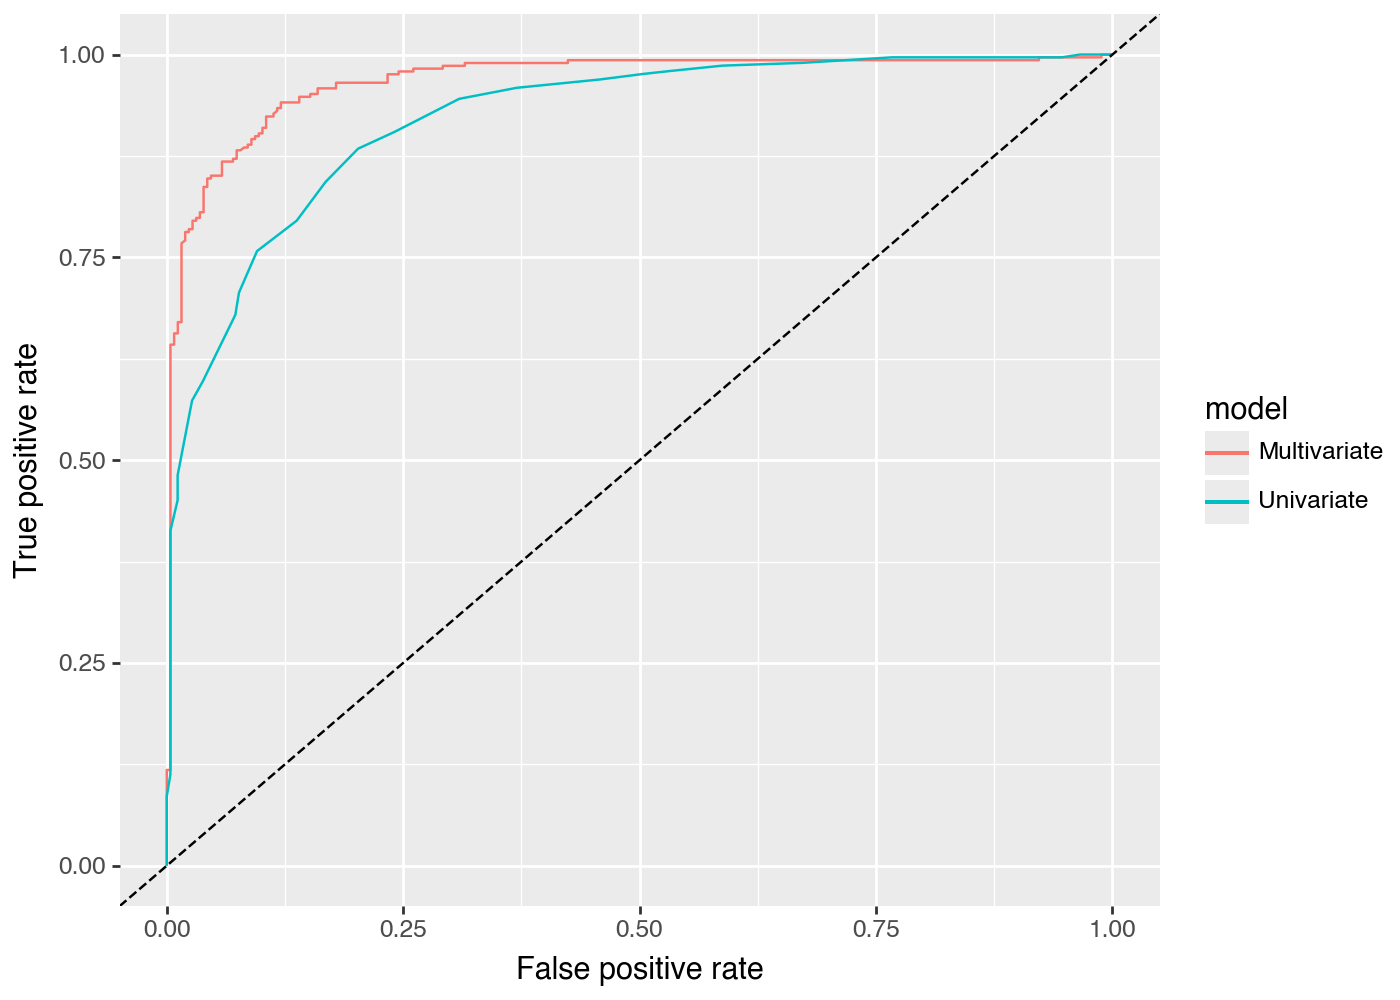

In [64]:
heights["multi_logistic_mu_hat"] = multi_logistic_fit.predict(heights)

roc_rows = []
for label, scores in [
  ("Univariate", heights["mu_hat"]),
  ("Multivariate", heights["multi_logistic_mu_hat"]),
]:
  # Drop any rows with missing scores to avoid NaNs in ROC computation
  mask = scores.notna()
  fpr, tpr, _ = roc_curve(heights.loc[mask, "y"], scores[mask])
  roc_rows.append(
    pd.DataFrame({"fpr": fpr, "tpr": tpr, "model": label})
  )

roc_df_multi = pd.concat(roc_rows, ignore_index=True)

ggroc = (
  ggplot(roc_df_multi, aes("fpr", "tpr", color="model"))
  + geom_line()
  + geom_abline(intercept=0, slope=1, linetype="dashed")
  + labs(x="False positive rate", y="True positive rate")
  + theme(figure_size=(7, 5))
)
ggroc

We can see that for lower values of false positive rates, the true positive rate is higher on the multiple logistic regression model. 

This suggests this model has a better performance. Classification performance can also be measured by the AUC (area under the ROC curve). 

The Area Under the Curve (AUC) condenses this performance into a single value: the probability that a randomly selected positive instance is ranked higher than a randomly selected negative one (as an exercise, prove it). 

An AUC of 1 means that the model is perfectly able to distinguish between the positive and negative classes. An AUC of 0.5, which corresponds to the AUC of a ROC curve which is a diagonal line, means the classifier model is no better than random classification.

In [65]:
auc_uni = roc_auc_score(heights["y"], heights["mu_hat"])
mask_multi = heights["multi_logistic_mu_hat"].notna()
auc_multi = roc_auc_score(
  heights.loc[mask_multi, "y"], heights.loc[mask_multi, "multi_logistic_mu_hat"]
)
auc_uni, auc_multi

(np.float64(0.9215668394862309), np.float64(0.9670409100734977))

The AUC for the multiple logistic regression is $\sim 0.970$, indicating a better classification performance compared to the univariate logistic regression (AUC $\sim 0.925$), which only takes the height of the student to predict its sex.

-----

# Precision Recall curve

Let’s compute the ROC curve and its AUC on the logistic regression on the imbalanced dataset.

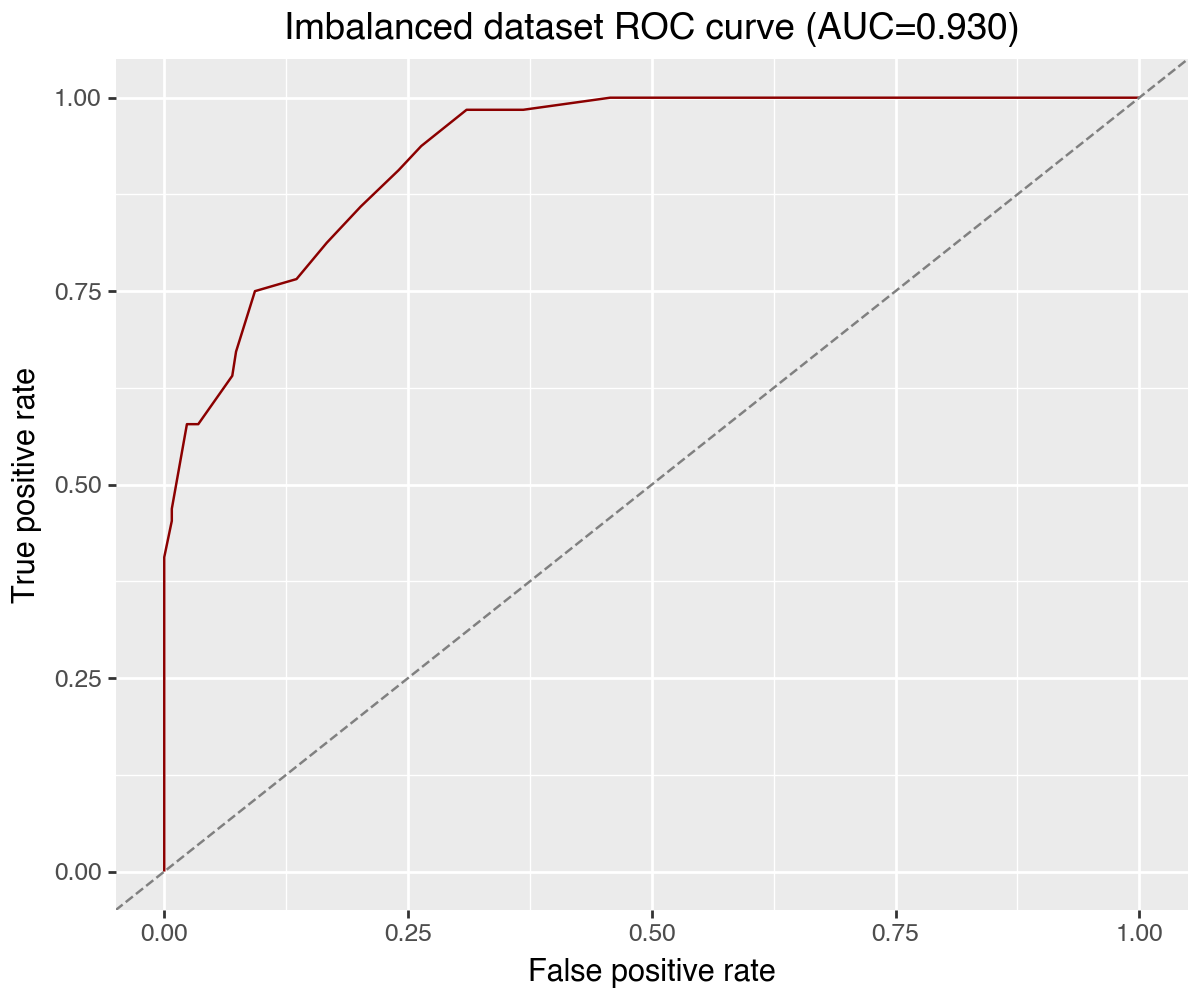

In [68]:
imbalanced_heights["mu_hat"] = logistic_fit_imbalanced.predict(imbalanced_heights)
fpr_imb, tpr_imb, _ = roc_curve(imbalanced_heights["y"], imbalanced_heights["mu_hat"])
auc_imb = roc_auc_score(imbalanced_heights["y"], imbalanced_heights["mu_hat"])

roc_imb_df = pd.DataFrame({"fpr": fpr_imb, "tpr": tpr_imb})

(
  ggplot(roc_imb_df, aes("fpr", "tpr"))
  + geom_line(color="darkred")
  + geom_abline(intercept=0, slope=1, linetype="dashed", color="grey")
  + labs(
      x="False positive rate",
      y="True positive rate",
      title=f"Imbalanced dataset ROC curve (AUC={auc_imb:.3f})",
    )
  + theme(figure_size=(6, 5))
)

From its AUC value, the performance of this model seems similar to the model on the balanced dataset. Let’s inspect such performances using a Precision Recall curve, which, for different cutoffs plots the precision ($\frac{TP}{TP + FP}$)against the recall ($\frac{TP}{P} = \frac{TP}{TP + FN}$). 

To plot a precision recall curve we can use the function from `sklearn.metrics`


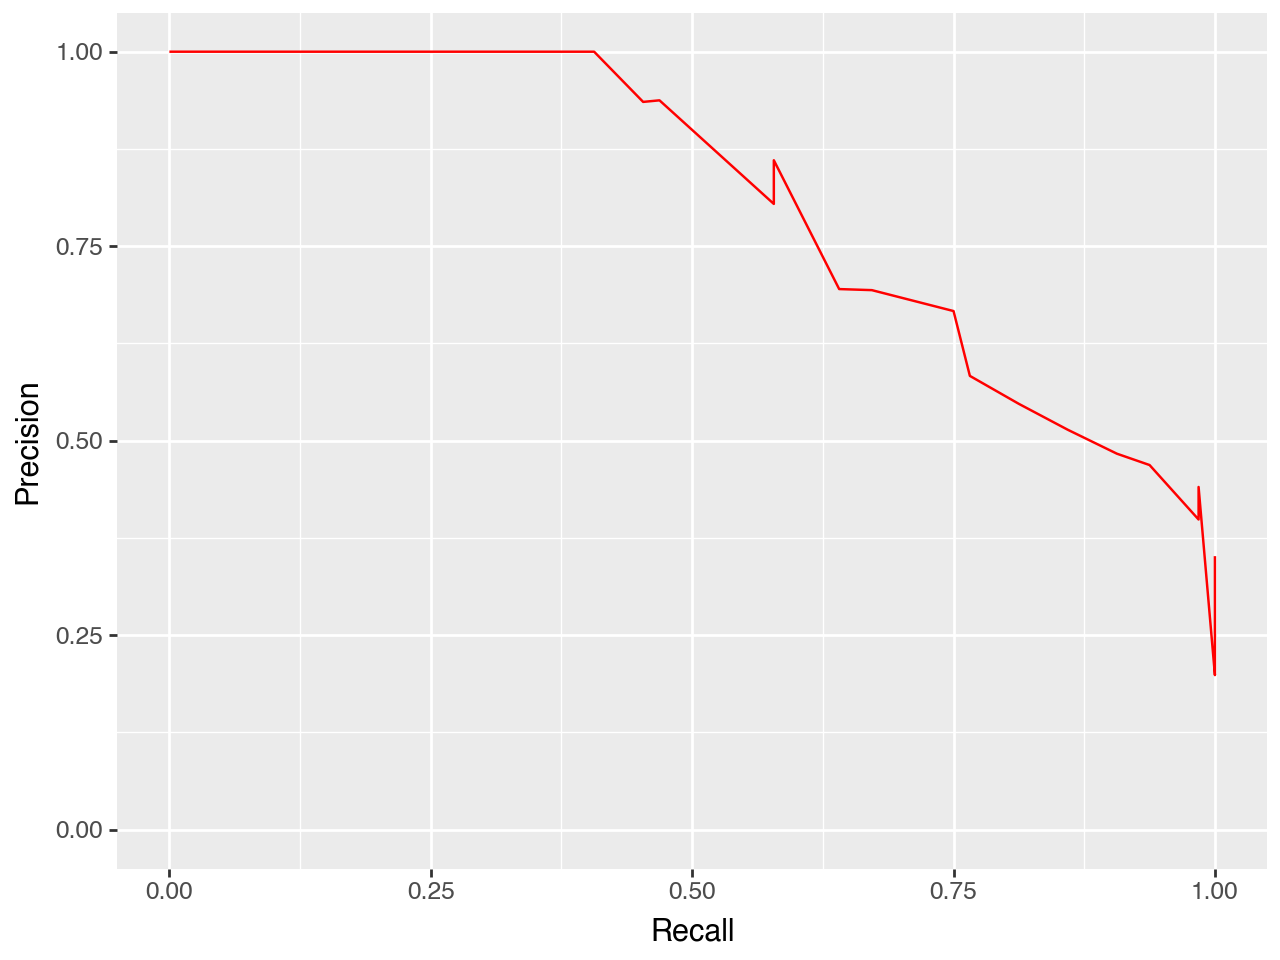

In [69]:
precision_imb, recall_imb, _ = precision_recall_curve(
    imbalanced_heights["y"], imbalanced_heights["mu_hat"]
)

pr_imb_df = pd.DataFrame({"precision": precision_imb, "recall": recall_imb})

(
  ggplot(pr_imb_df, aes("recall", "precision"))
  + geom_line(color="red")
  + labs(x="Recall", y="Precision")
  + scale_y_continuous(limits=(0, 1))
)

Now let’s plot the precision recall curve of the logistic regression model on the balanced dataset:

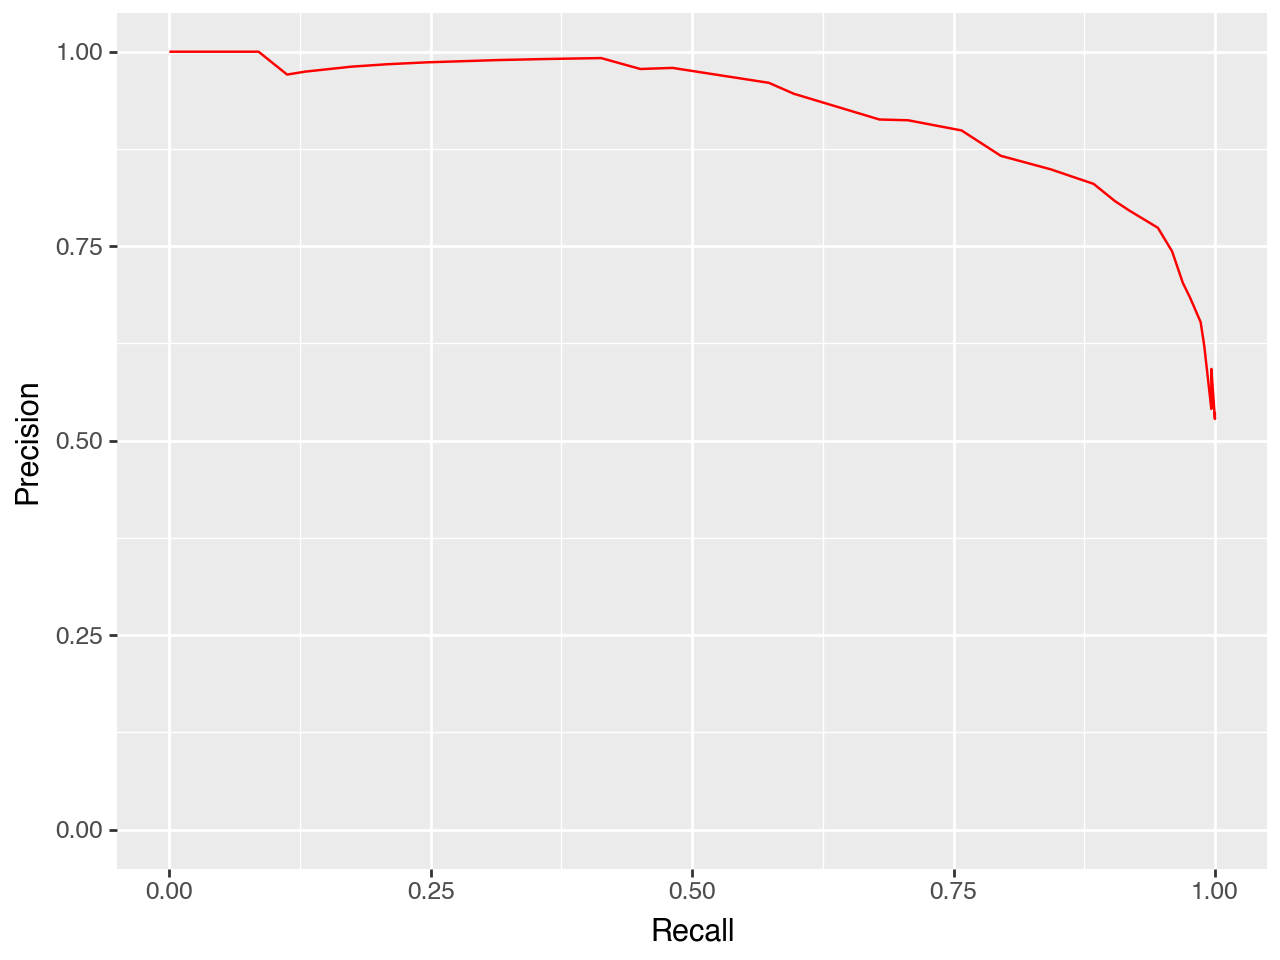

In [70]:
precision_bal, recall_bal, _ = precision_recall_curve(heights["y"], heights["mu_hat"])

pr_bal_df = pd.DataFrame({"precision": precision_bal, "recall": recall_bal})

(
  ggplot(pr_bal_df, aes("recall", "precision"))
  + geom_line(color="red")
  + labs(x="Recall", y="Precision")
  + scale_y_continuous(limits=(0, 1))
)

Although the ROC curves of both models look similar, the precision recall curves look different. 

Because the dataset is imbalanced for the female (negative class), the corresponding logistic regression model provides lower precisions for the same recall, meaning that such model is worse at classifying males. 

The PR curves is hence used in very imbalanced situations in which the positive class is strongly under-represented. These are “finding a needle in a haystack” situations, such as detecting a rare disease or retrieving a relevant web page among billions of web pages across the web. 

Then, the precision-recall curves emphasize better the performance of the model among the top scoring predictions than the ROC curve.

-----

# Calibration of Predicted Probabilities

The ROC and PR curves evaluate how well a model ranks positives above negatives (this is called <u>discrimination</u>). 

However, logistic regression outputs probabilities, and a different diagnostic question is often crucial:

    When the model predicts 0.8, do about 80% of such cases actually belong to the positive class?

This property is called <u>calibration</u>. 

Generally, a probabilistic model is calibrated if the estimated probabilities are accurate. 

Calibration is critical when deploying prediction models in real-world settings. Even models with strong discriminatory power may lead to flawed decisions if they misrepresent absolute risk.

Calibration is particularly important in clinical contexts, finance, insurance, severe weather forecast, etc.

For these application areas, calibration should be evaluated alongside discrimination and overall accuracy.

A model can have a good ROC-AUC (good ranking) but still be poorly calibrated (wrong probability scale).

One way to visualize calibration is the `reliability diagram` (also called a calibration curve).

To assess calibration, we can:

* Fit a probabilistic model and obtain predicted probabilities $\hat p$.

* Group predictions into bins and compare:
    * mean predicted probability in the bin
    * observed fraction of positives in the bin

    

If the model is perfectly calibrated, these points lie on the diagonal line $x = y$

In principle, calibration should be assessed on held-out data (otherwise there is a risk of overfitting, i.e., the model may look better calibrated than it really is on unseen data).

We will introduce train/test splitting and out-of-sample evaluation in the next Chapter. For now, we illustrate the idea on the same data used for fitting.

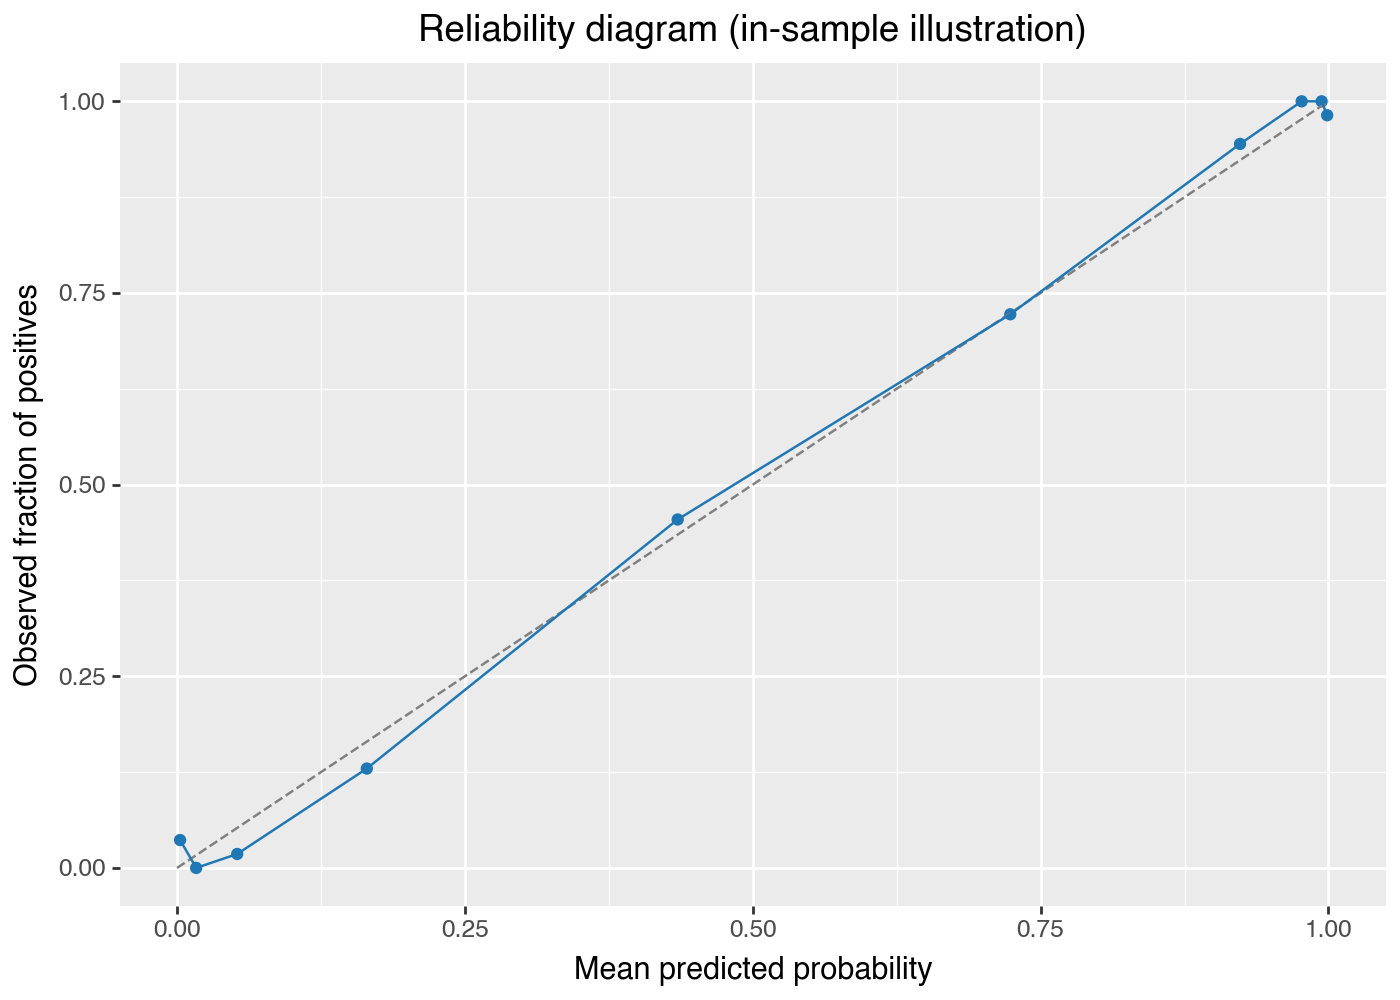

In [72]:
calib_df = heights.dropna(subset=["y", "height", "mother", "father"]).copy()

# Fit a multivariate logistic regression (same model as above)
calib_fit = smf.glm(
  "y ~ height + mother + father",
  data=calib_df,
  family=sm.families.Binomial(),
).fit()

calib_df["p_hat"] = calib_fit.predict(calib_df)
calib_df = calib_df.dropna(subset=["p_hat"])  # safety
calib_df["p_hat"] = calib_df["p_hat"].clip(0.0, 1.0)

# Compute calibration curve (quantile bins = similar counts per bin)
frac_pos, mean_pred = calibration_curve(
  calib_df["y"],
  calib_df["p_hat"],
  n_bins=10,
  strategy="quantile",
)

calib_curve_df = pd.DataFrame({"mean_pred": mean_pred, "frac_pos": frac_pos})
calib_curve_df = calib_curve_df.dropna().sort_values("mean_pred")

diag_df = pd.DataFrame({"x": [0, 1], "y": [0, 1]})

p_calib = (
  ggplot(calib_curve_df, aes("mean_pred", "frac_pos"))
  + geom_point(color="#1f77b4")
  + geom_line(diag_df, aes("x", "y"), linetype="dashed", color="grey")
  + labs(
      x="Mean predicted probability",
      y="Observed fraction of positives",
      title="Reliability diagram (in-sample illustration)",
  )
  + scale_x_continuous(limits=(0, 1))
  + scale_y_continuous(limits=(0, 1))
  + theme(figure_size=(7, 5))
)

if len(calib_curve_df) >= 2:
  p_calib = p_calib + geom_line(color="#1f77b4")

p_calib

Calibration and discriminative power are two distinct aspects of a classifier. A classifier can be perfectly calibrated without any discrimination power. For instance, a model predicting 50% chance to be male for any input values in a balanced population is well-calibrated, yet has no discriminative power.